# Libraries

In [344]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm
import os
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score, matthews_corrcoef, average_precision_score
import pickle
import re
from datetime import datetime
import warnings

# Import Predictions and Targets

In [215]:
SAVE_DIR = 'Models/GINe_baseline/Predictions'
df_train = pd.read_csv(f'{SAVE_DIR}/predictions_train_11_05_26.csv')
df_val   = pd.read_csv(f'{SAVE_DIR}/predictions_val_11_05_26.csv')
df_test = pd.read_csv(f'{SAVE_DIR}/predictions_test_11_05_26.csv')
df_all = pd.read_csv(f'{SAVE_DIR}/predictions_all_11_05_26.csv')


y_true_train = df_train['label'].values
y_score_train = df_train['score'].values

y_true_val  = df_val['label'].values
y_score_val = df_val['score'].values

y_true_test  = df_test['label'].values
y_score_test = df_test['score'].values

print(f"Test edges     : {len(df_test):,}")
print(f"Laundering     : {y_true_test.sum():,} ({100*y_true_test.mean():.4f}%)")
print(f"Score range    : [{y_score_test.min():.4f}, {y_score_test.max():.4f}]")

Test edges     : 1,384,810
Laundering     : 925 (0.0668%)
Score range    : [0.0002, 0.6746]


In [216]:
# Import PNA model predictions
SAVE_DIR = 'Models/PNA/Predictions'
df_train_pna = pd.read_csv(f'{SAVE_DIR}/predictions_train_pna_11_05_26.csv')
df_val_pna   = pd.read_csv(f'{SAVE_DIR}/predictions_val_pna_11_05_26.csv')
df_test_pna = pd.read_csv(f'{SAVE_DIR}/predictions_test_pna_11_05_26.csv')
df_all_pna = pd.read_csv(f'{SAVE_DIR}/predictions_all_pna_11_05_26.csv')

y_true_train_pna = df_train_pna['label'].values
y_score_train_pna = df_train_pna['score'].values

y_true_val_pna  = df_val_pna['label'].values
y_score_val_pna = df_val_pna['score'].values

y_true_test_pna  = df_test_pna['label'].values
y_score_test_pna = df_test_pna['score'].values

print(f"Test edges     : {len(df_test_pna):,}")
print(f"Laundering     : {y_true_test_pna.sum():,} ({100*y_true_test_pna.mean():.4f}%)")
print(f"Score range    : [{y_score_test_pna.min():.4f}, {y_score_test_pna.max():.4f}]")

Test edges     : 1,384,810
Laundering     : 925 (0.0668%)
Score range    : [0.0000, 0.9551]


# Metrics

In [53]:
def evaluate_aml_model(train_true, train_score, 
                       valid_true, valid_score, 
                       test_true, test_score):
    """
    Computes evaluation metrics across train, validation, and test splits.
    Optimizes thresholds for F1 and MCC solely on the validation data.
    """
    # Ensure inputs are numpy arrays
    train_true, train_score = np.array(train_true), np.array(train_score)
    valid_true, valid_score = np.array(valid_true), np.array(valid_score)
    test_true, test_score   = np.array(test_true), np.array(test_score)

    # ── 1. Find optimal thresholds on the TRAIN set ──────────────────────────
    precision, recall, thresholds = precision_recall_curve(valid_true, valid_score)
    
    # Optimize F1
    with np.errstate(divide='ignore', invalid='ignore'):
        f1_scores = 2 * (precision * recall) / (precision + recall)
    f1_scores = np.nan_to_num(f1_scores)
    best_f1_idx = np.argmax(f1_scores[:-1])
    best_thresh_f1 = thresholds[best_f1_idx]
    
    # Optimize MCC (Vectorized for speed on large graph datasets)
    P = np.sum(valid_true == 1)
    N = np.sum(valid_true == 0)
    
    TP = recall[:-1] * P
    FN = P - TP
    
    with np.errstate(divide='ignore', invalid='ignore'):
        # FP = TP / Precision - TP
        FP = np.where(precision[:-1] > 0, (TP / precision[:-1]) - TP, 0)
    TN = N - FP
    
    mcc_num = (TP * TN) - (FP * FN)
    mcc_den = np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
    
    with np.errstate(divide='ignore', invalid='ignore'):
        mcc_scores = np.divide(mcc_num, mcc_den, out=np.zeros_like(mcc_num), where=mcc_den!=0)
        
    best_mcc_idx = np.argmax(mcc_scores)
    best_thresh_mcc = thresholds[best_mcc_idx]

    # ── 2. Helper to evaluate a specific split ───────────────────────────────
    def evaluate_split(y_true, y_score, split_name):
        roc_auc = roc_auc_score(y_true, y_score)
        
        pr, rec, _ = precision_recall_curve(y_true, y_score)
        pr_auc = auc(rec, pr)
        
        # Apply train-optimized thresholds
        pred_f1  = (y_score >= best_thresh_f1).astype(int)
        pred_mcc = (y_score >= best_thresh_mcc).astype(int)
        
        split_f1 = f1_score(y_true, pred_f1)
        split_mcc = matthews_corrcoef(y_true, pred_mcc)
        
        return {
            'Split': split_name,
            'ROC_AUC': round(roc_auc*100, 2),
            'PR_AUC': round(pr_auc*100, 2),
            'F1_Score': round(split_f1*100, 2),
            'MCC': round(split_mcc*100, 2),
            'Thresh_F1_Used': round(best_thresh_f1, 4),
            'Thresh_MCC_Used': round(best_thresh_mcc, 4)
        }

    # ── 3. Evaluate all splits ───────────────────────────────────────────────
    results = [
        evaluate_split(train_true, train_score, 'Train'),
        evaluate_split(valid_true, valid_score, 'Validation'),
        evaluate_split(test_true, test_score, 'Test')
    ]
    
    # ── 4. Return formatted DataFrame ────────────────────────────────────────
    df_results = pd.DataFrame(results)
    
    # Optional: reorder and round columns for better readability
    df_results = df_results.round(4)
    df_results.set_index('Split', inplace=True)
    
    return df_results

In [54]:
metrics_df = evaluate_aml_model(
    train_true=y_true_train, train_score=y_score_train,
    valid_true=y_true_val, valid_score=y_score_val,
    test_true=y_true_test, test_score=y_score_test
)

print("Baseline GINe Model Performance:")

display(metrics_df)

Baseline GINe Model Performance:


,ROC_AUC,PR_AUC,F1_Score,MCC,Thresh_F1_Used,Thresh_MCC_Used
Split,,,,,,
Train,96.59,2.60,7.10,11.05,0.5472,0.4336
Validation,95.81,3.47,9.75,12.57,0.5472,0.4336
Test,96.18,3.46,9.62,13.02,0.5472,0.4336


In [55]:
metrics_df_pna = evaluate_aml_model(
    train_true=y_true_train_pna, train_score=y_score_train_pna,
    valid_true=y_true_val_pna, valid_score=y_score_val_pna,
    test_true=y_true_test_pna, test_score=y_score_test_pna
)

print("PNA Model Performance:")

display(metrics_df_pna)

PNA Model Performance:


,ROC_AUC,PR_AUC,F1_Score,MCC,Thresh_F1_Used,Thresh_MCC_Used
Split,,,,,,
Train,97.54,16.94,19.47,26.23,0.4079,0.6429
Validation,96.78,16.08,21.92,27.42,0.4079,0.6429
Test,97.29,24.08,27.71,35.35,0.4079,0.6429


# Ranking Plot

In [56]:
# def plot_score_bins(y_true, y_score, n_bins=50, title="GINe Baseline — Test Set Score Distribution"):
#     """
#     Plots score-bin analysis for AML model evaluation.
    
#     - X axis : n_bins equal-percentile bins (bin 1 = lowest scores, bin n = highest)
#     - Left Y  : % distribution of legit (blue bars) and laundering (red bars) transactions
#     - Right Y : laundering rate within each bin (orange line) + CDF of launderings (green line)
#     """
#     y_true  = np.array(y_true)
#     y_score = np.array(y_score)

#     # ── 1. Assign each edge to a percentile bin ───────────────────────────────
#     bin_edges   = np.percentile(y_score, np.linspace(0, 100, n_bins + 1))
#     bin_edges[0]  -= 1e-9   # include the minimum
#     bin_edges[-1] += 1e-9   # include the maximum
#     bin_ids = np.digitize(y_score, bin_edges) - 1
#     bin_ids = np.clip(bin_ids, 0, n_bins - 1)

#     # ── 2. Counts per bin ─────────────────────────────────────────────────────
#     legit_counts  = np.zeros(n_bins)
#     laund_counts  = np.zeros(n_bins)
#     for b in range(n_bins):
#         mask            = bin_ids == b
#         legit_counts[b] = np.sum((y_true[mask] == 0))
#         laund_counts[b] = np.sum((y_true[mask] == 1))

#     total_legit = legit_counts.sum()
#     total_laund = laund_counts.sum()

#     legit_pct  = 100 * legit_counts / total_legit   # sums to 100
#     laund_pct  = 100 * laund_counts / total_laund   # sums to 100

#     # Laundering rate = launderings / (launderings + legit) per bin
#     total_counts  = legit_counts + laund_counts
#     laund_rate    = 100 * laund_counts / np.where(total_counts > 0, total_counts, 1)

#     # CDF of launderings (cumulative % of all launderings captured up to bin b)
#     laund_cdf     = 100 * np.cumsum(laund_counts) / total_laund

#     # ── 3. Plot ───────────────────────────────────────────────────────────────
#     fig, ax1 = plt.subplots(figsize=(16, 6))
#     ax2 = ax1.twinx()

#     x = np.arange(1, n_bins + 1)
#     width = 0.4

#     bars_legit = ax1.bar(x - width/2, legit_pct, width=width,
#                          color='steelblue', alpha=0.7, label='Legit transactions (%)')
#     bars_laund = ax1.bar(x + width/2, laund_pct, width=width,
#                          color='firebrick', alpha=0.8, label='Laundering transactions (%)')

#     line_rate = ax2.plot(x, laund_rate, color='darkorange', linewidth=2,
#                          marker='o', markersize=3, label='Laundering rate (%)')
#     line_cdf  = ax2.plot(x, laund_cdf,  color='green',      linewidth=2,
#                          linestyle='--', marker='s', markersize=3,
#                          label='CDF of launderings (%)')

#     # ── 4. Annotations ───────────────────────────────────────────────────────
#     # # Mark the bin where rate exceeds 1% and 10%
#     # for threshold, color in [(1, 'orange'), (10, 'red')]:
#     #     bins_above = np.where(laund_rate >= threshold)[0]
#     #     if len(bins_above):
#     #         first_bin = bins_above[0] + 1
#     #         ax2.axvline(first_bin, color=color, linestyle=':', alpha=0.6,
#     #                     label=f'Rate ≥ {threshold}% (bin {first_bin})')

#     ax1.set_xlabel(f'Score Bin (1 = lowest score, {n_bins} = highest score)', fontsize=11)
#     ax1.set_ylabel('% of class transactions in bin', fontsize=11)
#     ax2.set_ylabel('Laundering rate / CDF (%)', fontsize=11)
#     ax1.set_title(title, fontsize=13, fontweight='bold')
#     ax1.set_xlim(0.5, n_bins + 0.5)
#     ax1.set_xticks(x[::5 if n_bins > 20 else 1])

#     # Combine legends
#     # handles1, labels1 = ax1.get_legend_handles_labels()
#     # handles2, labels2 = ax2.get_legend_handles_labels()
#     # ax1.legend(handles1 + handles2, labels1 + labels2,
#     #            loc='upper left', fontsize=8, framealpha=0.9)

#     # Replace the existing legend block with this:
#     handles1, labels1 = ax1.get_legend_handles_labels()
#     handles2, labels2 = ax2.get_legend_handles_labels()
#     ax1.legend(handles1 + handles2, labels1 + labels2,
#                loc='upper left',
#                bbox_to_anchor=(0.0, -0.12),   # below the plot
#                ncol=3,                          # 3 columns so it stays compact
#                fontsize=8,
#                framealpha=0.9)

#     ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
#     ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
#     ax1.grid(axis='y', alpha=0.3)

#     # ── 5. Summary text box ──────────────────────────────────────────────────
#     top5_capture = laund_cdf[-1] - (laund_cdf[-6] if n_bins >= 6 else 0)
#     top10_capture = laund_cdf[-1] - (laund_cdf[-11] if n_bins >= 11 else 0)
#     summary = (f"Total eval edges : {len(y_true):,}\n"
#                f"Launderings      : {int(total_laund):,} ({100*total_laund/len(y_true):.4f}%)\n"
#                f"Top-5 bins capture  : {top5_capture:.1f}% of launderings\n"
#                f"Top-10 bins capture : {top10_capture:.1f}% of launderings")
#     ax1.text(0.01, 0.97, summary, transform=ax1.transAxes, fontsize=8,
#              verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

#     plt.tight_layout()
#     # os.makedirs('plots', exist_ok=True)
#     # plt.savefig(f'plots/score_bin_analysis_{n_bins}bins.png', dpi=150, bbox_inches='tight')
#     plt.show()
#     # print(f"Saved to plots/score_bin_analysis_{n_bins}bins.png")

In [57]:
# # ── Usage ─────────────────────────────────────────────────────────────────────
# # Run inference on test set

# plot_score_bins(y_true_test, y_score_test, n_bins=40)

In [58]:
def plot_score_bins(y_true, y_score, n_bins=50, title="GINe Baseline — Test Set Score Distribution"):
    """
    Plots score-bin analysis for AML model evaluation.
    
    - X axis : n_bins equal-percentile bins (bin 1 = lowest scores, bin n = highest)
    - Left Y  : % distribution of legit (blue bars) and laundering (red bars) transactions
    - Right Y : laundering rate within each bin (orange line) + Cumulative laundering rate (green line)
    """
    y_true  = np.array(y_true)
    y_score = np.array(y_score)

    # ── 1. Assign each edge to a percentile bin ───────────────────────────────
    bin_edges   = np.percentile(y_score, np.linspace(0, 100, n_bins + 1))
    bin_edges[0]  -= 1e-9   # include the minimum
    bin_edges[-1] += 1e-9   # include the maximum
    bin_ids = np.digitize(y_score, bin_edges) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    # ── 2. Counts per bin ─────────────────────────────────────────────────────
    legit_counts  = np.zeros(n_bins)
    laund_counts  = np.zeros(n_bins)
    for b in range(n_bins):
        mask            = bin_ids == b
        legit_counts[b] = np.sum((y_true[mask] == 0))
        laund_counts[b] = np.sum((y_true[mask] == 1))

    total_legit = legit_counts.sum()
    total_laund = laund_counts.sum()

    legit_pct  = 100 * legit_counts / total_legit   # sums to 100
    laund_pct  = 100 * laund_counts / total_laund   # sums to 100

    # Laundering rate = launderings / (launderings + legit) per bin
    total_counts  = legit_counts + laund_counts
    laund_rate    = 100 * laund_counts / np.where(total_counts > 0, total_counts, 1)

    # CDF of launderings (Kept internally so the Summary Text Box doesn't break)
    laund_cdf     = 100 * np.cumsum(laund_counts) / total_laund

    # --- NEW: Cumulative Laundering Rate (Bottom-Up) ---
    # Cumulative laundering transactions / cumulative total transactions (from bin 1 to b)
    cum_laund_counts = np.cumsum(laund_counts)
    cum_total_counts = np.cumsum(total_counts)
    cum_laund_rate = 100 * cum_laund_counts / np.where(cum_total_counts > 0, cum_total_counts, 1)

    # --- ALTERNATIVE: Cumulative Laundering Rate (Top-Down / Precision) ---
    # If you prefer to see the cumulative rate starting from the HIGHEST scores down:
    # cum_laund_top_down = np.cumsum(laund_counts[::-1])[::-1]
    # cum_total_top_down = np.cumsum(total_counts[::-1])[::-1]
    # cum_laund_rate_top_down = 100 * cum_laund_top_down / np.where(cum_total_top_down > 0, cum_total_top_down, 1)

    # ── 3. Plot ───────────────────────────────────────────────────────────────
    fig, ax1 = plt.subplots(figsize=(16, 6))
    ax2 = ax1.twinx()

    x = np.arange(1, n_bins + 1)
    width = 0.4

    bars_legit = ax1.bar(x - width/2, legit_pct, width=width,
                         color='steelblue', alpha=0.7, label='Legit transactions (%)')
    bars_laund = ax1.bar(x + width/2, laund_pct, width=width,
                         color='firebrick', alpha=0.8, label='Laundering transactions (%)')

    line_rate = ax2.plot(x, laund_rate, color='darkorange', linewidth=2,
                         marker='o', markersize=3, label='Laundering rate (%)')
    
    # Plotting the newly calculated Cumulative Rate
    line_cum_rate = ax2.plot(x, cum_laund_rate, color='green', linewidth=2,
                             linestyle='--', marker='s', markersize=3,
                             label='Cumulative Laund. Rate (%)')

    # ── 4. Annotations ───────────────────────────────────────────────────────
    ax1.set_xlabel(f'Score Bin (1 = lowest score, {n_bins} = highest score)', fontsize=11)
    ax1.set_ylabel('% of class transactions in bin', fontsize=11)
    ax2.set_ylabel('Laundering rate / Cum. Rate (%)', fontsize=11)
    ax1.set_title(title, fontsize=13, fontweight='bold')
    ax1.set_xlim(0.5, n_bins + 0.5)
    ax1.set_xticks(x[::5 if n_bins > 20 else 1])

    # Replace the existing legend block
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(handles1 + handles2, labels1 + labels2,
               loc='upper left',
               bbox_to_anchor=(0.0, -0.12),   # below the plot
               ncol=4,                        # adjusted to 4 columns for new labels
               fontsize=8,
               framealpha=0.9)

    ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    ax1.grid(axis='y', alpha=0.3)

    # ── 5. Summary text box ──────────────────────────────────────────────────
    top5_capture = laund_cdf[-1] - (laund_cdf[-6] if n_bins >= 6 else 0)
    top10_capture = laund_cdf[-1] - (laund_cdf[-11] if n_bins >= 11 else 0)
    summary = (f"Total eval edges : {len(y_true):,}\n"
               f"Launderings      : {int(total_laund):,} ({100*total_laund/len(y_true):.4f}%)\n"
               f"Top-5 bins capture  : {top5_capture:.1f}% of launderings\n"
               f"Top-10 bins capture : {top10_capture:.1f}% of launderings")
    ax1.text(0.01, 0.97, summary, transform=ax1.transAxes, fontsize=8,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.show()

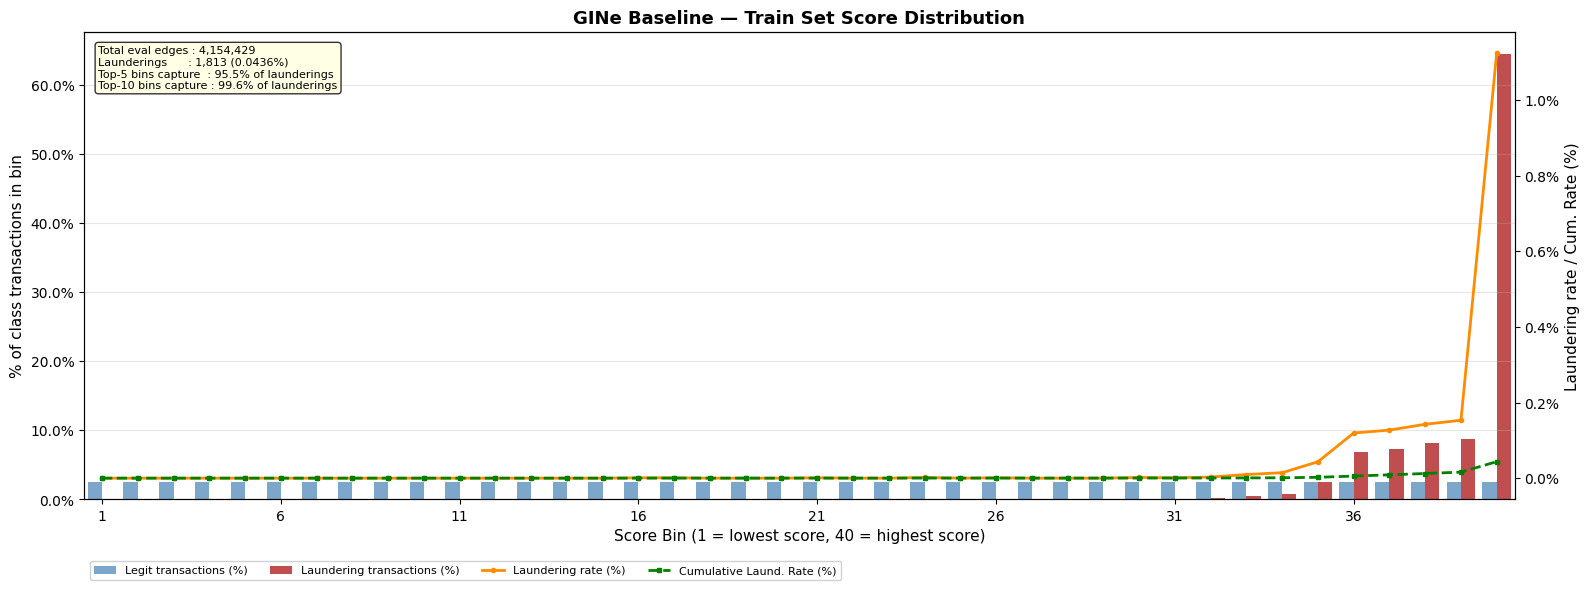

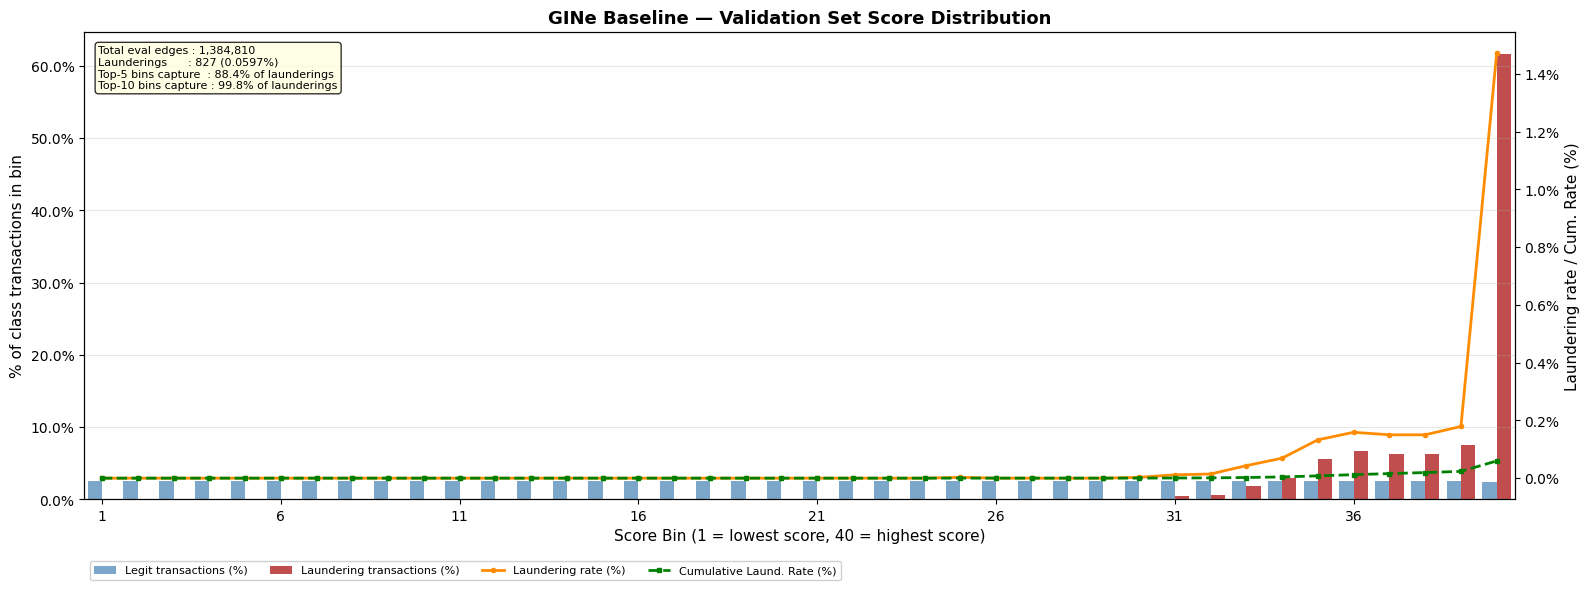

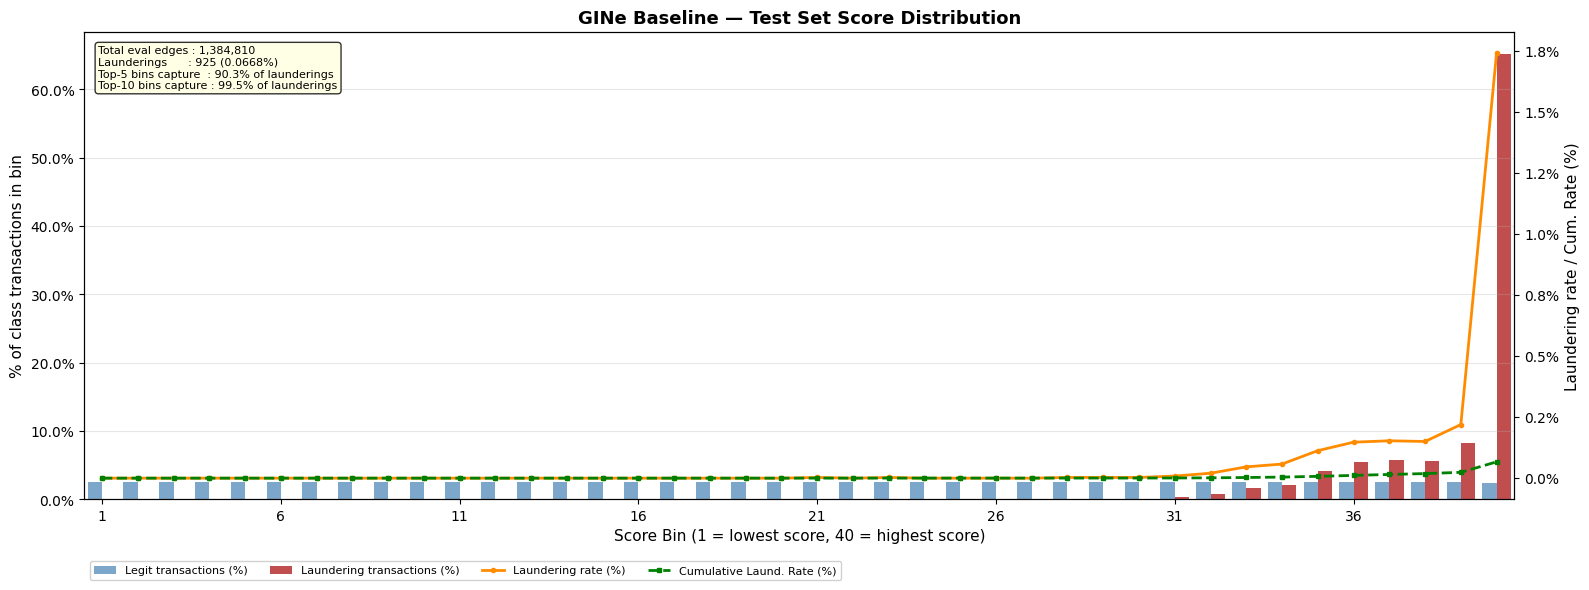

In [61]:
# ── Usage ─────────────────────────────────────────────────────────────────────
# Run inference on test set

plot_score_bins(y_true_train, y_score_train, n_bins=40, title="GINe Baseline — Train Set Score Distribution")
plot_score_bins(y_true_val, y_score_val, n_bins=40, title="GINe Baseline — Validation Set Score Distribution")
plot_score_bins(y_true_test, y_score_test, n_bins=40, title="GINe Baseline — Test Set Score Distribution")

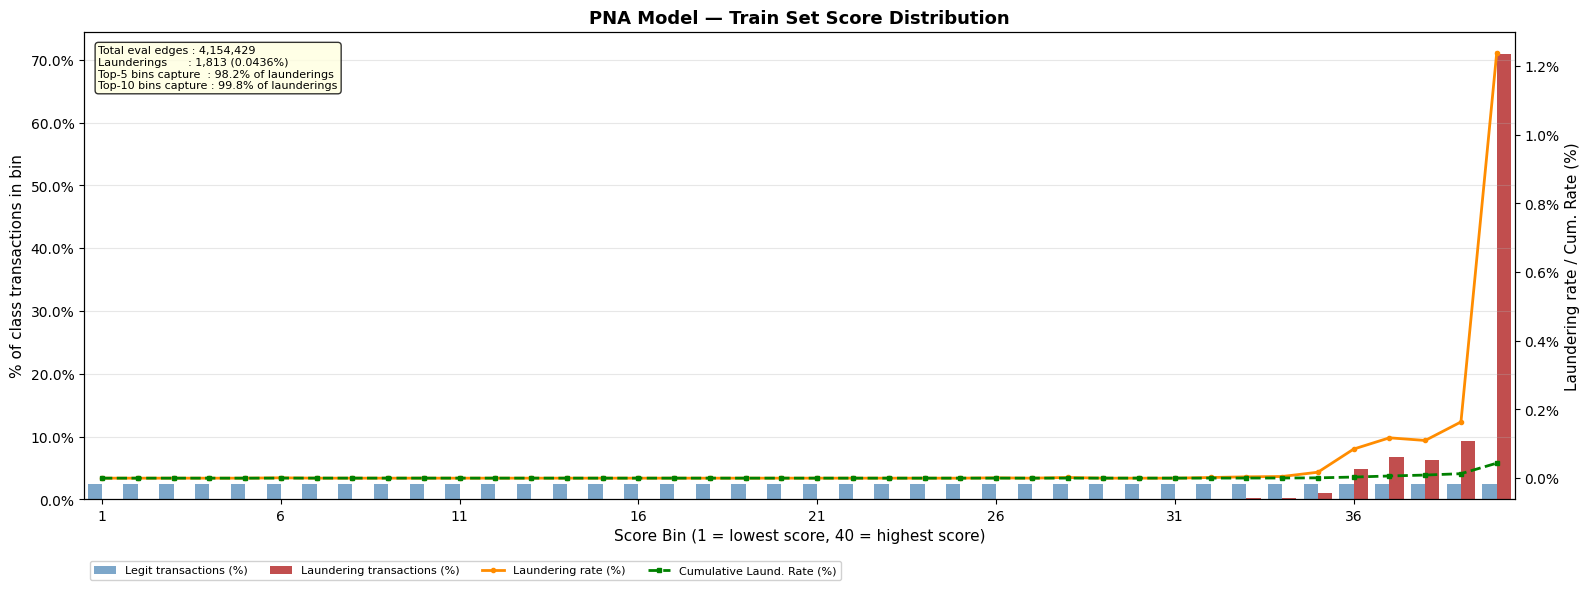

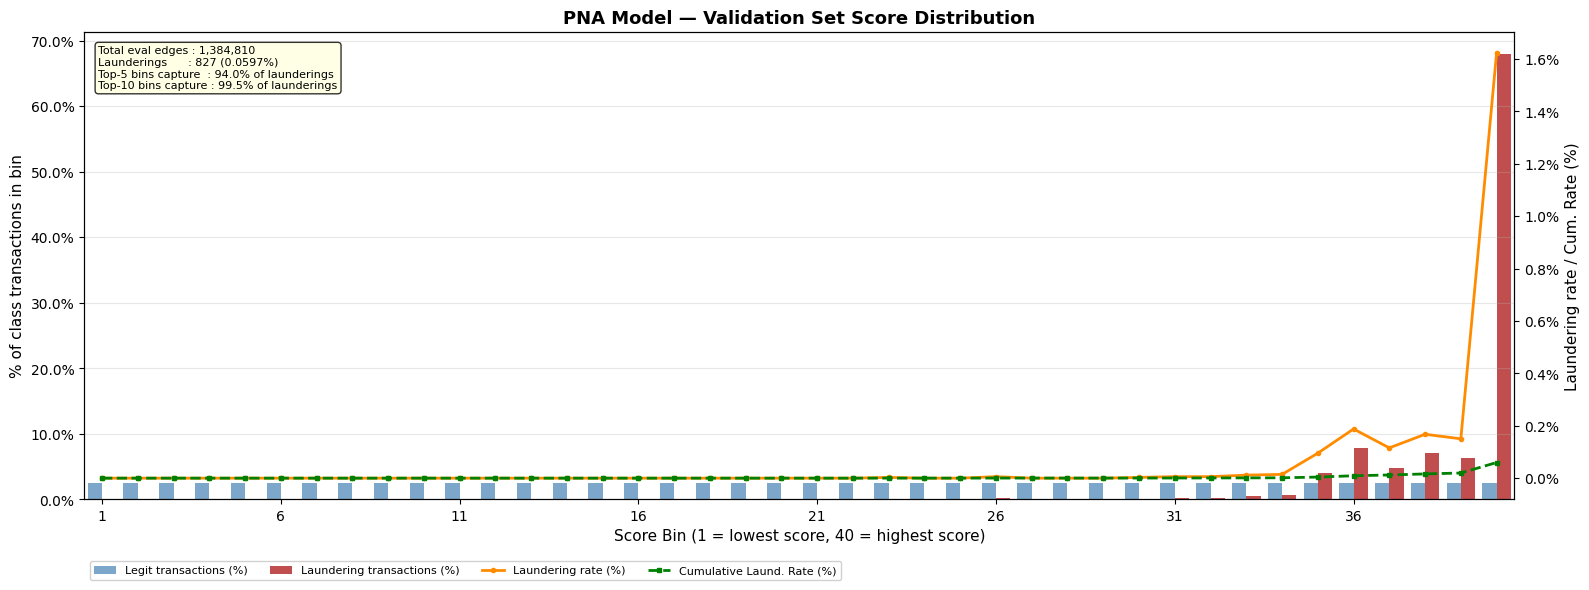

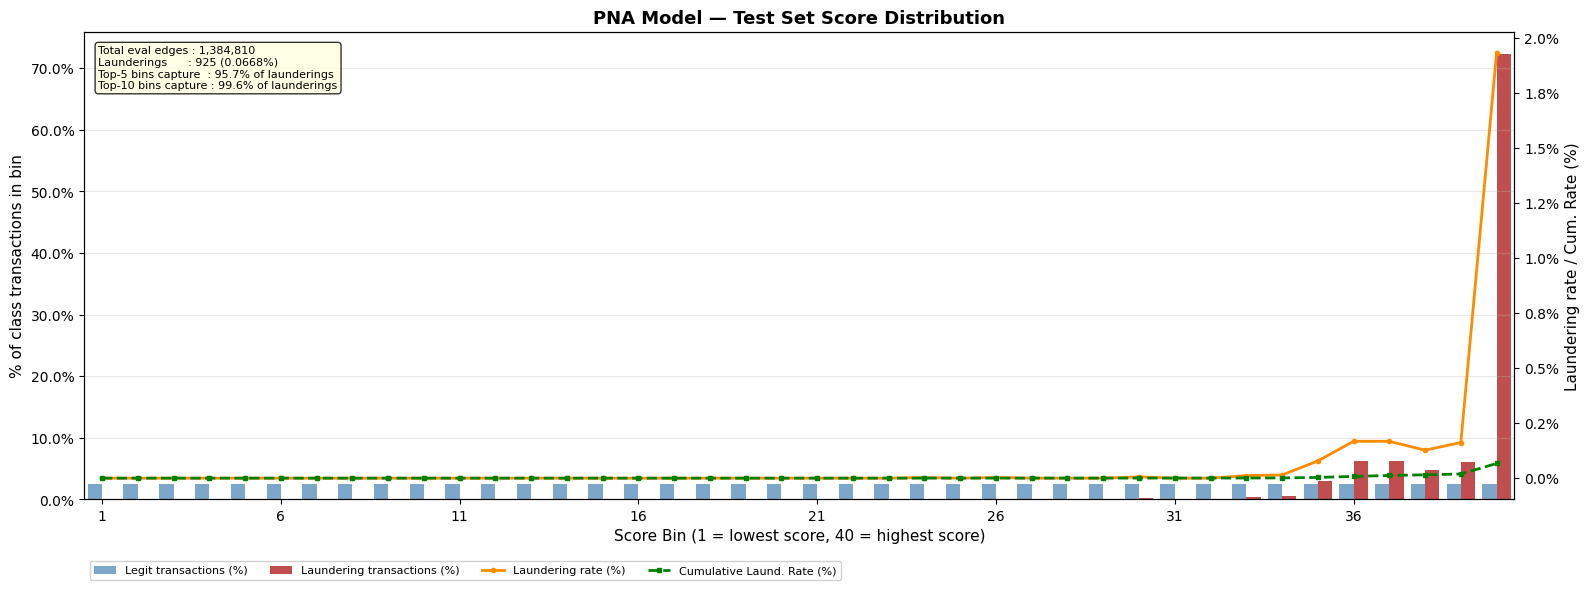

In [62]:
# Ranking plots for the PNA model

plot_score_bins(y_true_train_pna, y_score_train_pna, n_bins=40, title="PNA Model — Train Set Score Distribution")
plot_score_bins(y_true_val_pna, y_score_val_pna, n_bins=40, title="PNA Model — Validation Set Score Distribution")
plot_score_bins(y_true_test_pna, y_score_test_pna, n_bins=40, title="PNA Model — Test Set Score Distribution")

# Precision@K, Recall@K

In [132]:
def evaluate_top_k(y_true, y_score_pna, y_score_gine,
                   k_percentages=[1, 5, 10, 15, 20, 25]):
    """
    Calculates and plots Precision@K and Recall@K comparing two models.

    Parameters
    ----------
    y_true         : array-like, true binary labels (0 or 1)
    y_score_pna    : array-like, predicted probabilities from PNA
    y_score_gine   : array-like, predicted probabilities from GINe
    k_percentages  : list of ints, top K% thresholds to evaluate
    """
    y_true          = np.array(y_true)
    total_samples   = len(y_true)
    total_positives = int(np.sum(y_true))

    colors = {'PNA': 'firebrick', 'GINe Baseline': 'steelblue'}

    def get_k_metrics(scores, model_name):
        sorted_idx    = np.argsort(scores)[::-1]
        sorted_labels = y_true[sorted_idx]
        rows = []
        for k in k_percentages:
            n_top = max(1, int(total_samples * k / 100.0))
            tp    = np.sum(sorted_labels[:n_top])
            rows.append({
                'K%'       : k,
                'Precision': tp / n_top,
                'Recall'   : tp / total_positives,
                'Model'    : model_name,
            })
        return pd.DataFrame(rows)

    df_pna  = get_k_metrics(y_score_pna,  'PNA')
    df_gine = get_k_metrics(y_score_gine, 'GINe Baseline')
    df_all  = pd.concat([df_pna, df_gine], ignore_index=True)

    # ── Print comparison table ────────────────────────────────────────────────
    pivot_df = df_all.pivot(index='K%', columns='Model', values=['Precision', 'Recall'])
    print(f"\nTop-K Metrics Comparison")
    print(f"Total test edges : {total_samples:,}  |  Launderers : {total_positives:,}\n")
    print(f"{'Top K%':<8} | {'PNA Precision':<15} | {'GINe Precision':<15} | {'PNA Recall':<12} | {'GINe Recall':<12}")
    print("-" * 73)
    for k in k_percentages:
        print(f"{k:>6}% | "
              f"{pivot_df.loc[k, ('Precision', 'PNA')]:>14.2%} | "
              f"{pivot_df.loc[k, ('Precision', 'GINe Baseline')]:>14.2%} | "
              f"{pivot_df.loc[k, ('Recall',    'PNA')]:>11.1%} | "
              f"{pivot_df.loc[k, ('Recall',    'GINe Baseline')]:>11.1%}")

    # ── Label offsets ─────────────────────────────────────────────────────────
    # Vertical: PNA above point, GINe below — tuned per metric scale
    v_offsets = {
        'Precision': {'PNA': +0.001, 'GINe Baseline': -0.003},
        'Recall'   : {'PNA': +0.015,   'GINe Baseline': -0.035  },
    }
    # Horizontal: PNA left of point, GINe right — prevents overlap at same x
    h_offsets = {
        'Precision': {'PNA': +0.5, 'GINe Baseline': -0.3},
        'Recall'   : {'PNA': -0.3, 'GINe Baseline': +0.3},
    }

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, metric, ylabel, fmt in [
        (axes[0], 'Precision', 'Precision — out of flagged, % are real launderings', '{:.2%}'),
        (axes[1], 'Recall',    'Recall — out of all launderings, % are caught',      '{:.0%}'),
    ]:
        for model_name, color in colors.items():
            subset = df_all[df_all['Model'] == model_name]
            ax.plot(subset['K%'], subset[metric],
                    color=color, linewidth=2.5,
                    marker='o', markersize=7,
                    label=model_name)

            for _, row in subset.iterrows():
                ax.text(row['K%'] + h_offsets[metric][model_name],
                        row[metric] + v_offsets[metric][model_name],
                        fmt.format(row[metric]),
                        fontsize=7.5, color=color, fontweight='bold',
                        ha='center', va='bottom')

        ax.set_xlabel('Top K% of transactions reviewed (highest scores first)', fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(f'{metric} @ Top K%', fontsize=13, fontweight='bold')
        ax.set_xticks(k_percentages)
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d%%'))
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: fmt.format(y)))
        ax.set_ylim(bottom=0)
        ax.grid(alpha=0.3)
        ax.legend(loc='upper right', bbox_to_anchor=(1.0, 0.85),
                  fontsize=8, framealpha=0.9)

    # Summary box — top right of precision plot, away from the K=1% spike
    summary = (f"Total eval edges : {total_samples:,}\n"
               f"Launderings      : {total_positives:,} ({100*total_positives/total_samples:.4f}%)")
    axes[0].text(0.97, 0.97, summary, transform=axes[0].transAxes, fontsize=8,
                 verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.show()

    return df_all


Top-K Metrics Comparison
Total test edges : 1,384,810  |  Launderers : 925

Top K%   | PNA Precision   | GINe Precision  | PNA Recall   | GINe Recall 
-------------------------------------------------------------------------
     1% |          4.27% |          3.37% |       64.0% |       50.5%
     5% |          1.05% |          0.98% |       78.4% |       73.4%
    10% |          0.60% |          0.57% |       89.4% |       84.8%
    15% |          0.44% |          0.42% |       98.6% |       94.5%
    20% |          0.33% |          0.33% |       99.6% |       98.4%
    25% |          0.27% |          0.27% |       99.6% |       99.5%


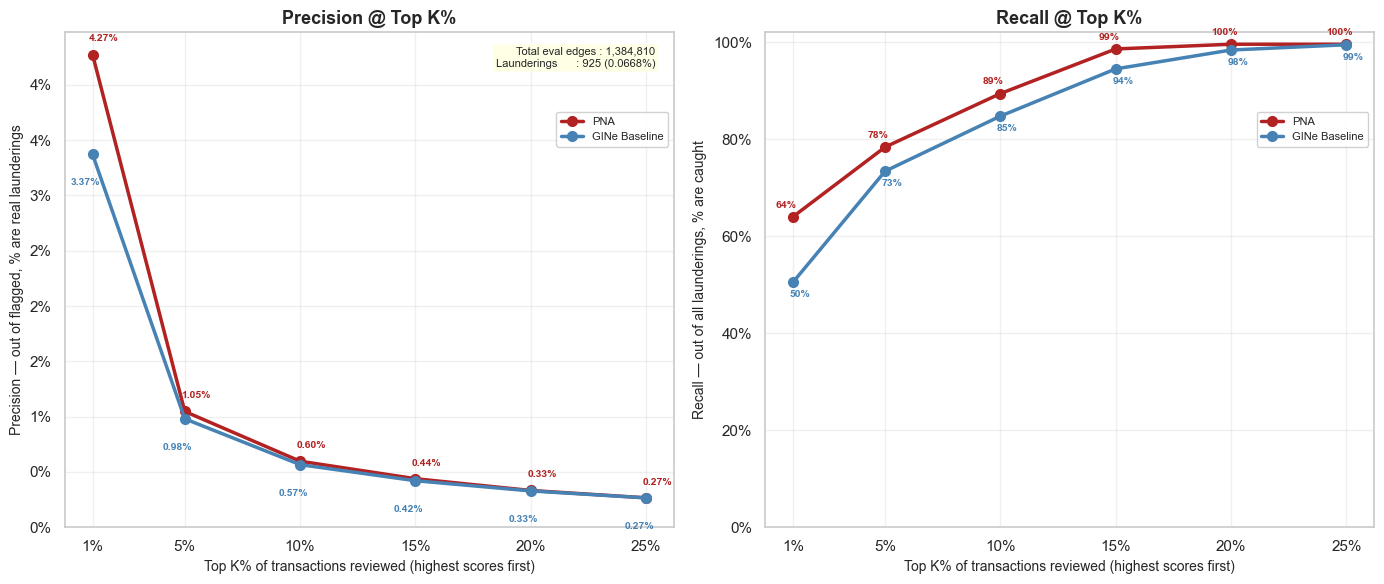

In [133]:
# ── Usage ─────────────────────────────────────────────────────────────────────
df_top_k = evaluate_top_k(
    y_true=y_true_test, 
    y_score_pna=y_score_test_pna, 
    y_score_gine=y_score_test,
    k_percentages=[1, 5, 10, 15, 20, 25]
)

# CDF, cumulative laundering distribution

In [85]:
def plot_laundering_cdf_comparison(
    y_true,
    scores_dict,
    n_bins=50,
    title="Cumulative Laundering Capture — Model Comparison"
):
    """
    Plots the CDF of laundering capture for multiple models on the same axes.

    Parameters
    ----------
    y_true      : array-like, ground truth labels (0=legit, 1=laundering)
    scores_dict : dict of {model_name: y_score}, e.g.
                  {'GINe Baseline': y_score_gine, 'PNA': y_score_pna}
    n_bins      : number of equal-percentile bins
    title       : plot title

    The CDF answers: "As I review transactions from lowest to highest score,
    what % of all launderings have I captured by bin k?"
    """
    y_true      = np.array(y_true)
    total_laund = (y_true == 1).sum()

    colors      = ['steelblue', 'firebrick', 'darkorange', 'purple', 'teal']
    model_names = list(scores_dict.keys())

    fig, ax = plt.subplots(figsize=(10, 6))

    for idx, (model_name, y_score) in enumerate(scores_dict.items()):
        color   = colors[idx % len(colors)]
        y_score = np.array(y_score)

        # ── Bin assignment ────────────────────────────────────────────────────
        bin_edges     = np.percentile(y_score, np.linspace(0, 100, n_bins + 1))
        bin_edges[0]  -= 1e-9
        bin_edges[-1] += 1e-9
        bin_ids = np.digitize(y_score, bin_edges) - 1
        bin_ids = np.clip(bin_ids, 0, n_bins - 1)

        # ── Laundering counts per bin ─────────────────────────────────────────
        laund_counts = np.zeros(n_bins)
        for b in range(n_bins):
            laund_counts[b] = np.sum(y_true[bin_ids == b] == 1)

        # ── CDF from bottom bin upward ────────────────────────────────────────
        cdf_bottom_up = 100 * np.cumsum(laund_counts) / total_laund

        x = np.arange(1, n_bins + 1)

        # Key summary stats
        pct_at_40 = cdf_bottom_up[39]   # capture rate by bin 40 (reviewing 80% of transactions)
        pct_at_45 = cdf_bottom_up[44]   # capture rate by bin 45 (reviewing 90%)
        pct_at_48 = cdf_bottom_up[47]   # capture rate by bin 48 (reviewing 96%)

        label = (f"{model_name}  "
                f"[by bin 40: {pct_at_40:.1f}%  |  "
                f"by bin 45: {pct_at_45:.1f}%  |  "
                f"by bin 48: {pct_at_48:.1f}%]")

        ax.plot(x, cdf_bottom_up, color=color, linewidth=2.5,
                marker='o', markersize=3, label=label)

        # # ── Annotations: vertical drop-lines + staggered labels ──────────────
        # for ref_bin, ref_val in [
        #     (n_bins - 4,  top5_pct),
        #     (n_bins - 9, top10_pct),
        # ]:
        #     # Dotted vertical reference line from x-axis up to the curve
        #     ax.plot([ref_bin, ref_bin], [0, ref_val],
        #             color=color, linewidth=0.8, linestyle=':', alpha=0.5)
        #     # Label staggered vertically by model index to prevent overlap
        #     ax.text(ref_bin,
        #             ref_val + 3 + idx * 6,
        #             f'{ref_val:.1f}%',
        #             fontsize=8, color=color, fontweight='bold',
        #             ha='center')

    # ── Random baseline ───────────────────────────────────────────────────────
    ax.plot(x, np.linspace(100/n_bins, 100, n_bins),
            color='gray', linewidth=1.5, linestyle=':', label='Random baseline')

    # ── Formatting ────────────────────────────────────────────────────────────
    ax.set_xlabel(f'Score Bin (1 = lowest score, {n_bins} = highest score)\n'
                  f'← fewer launderings captured         more captured →',
                  fontsize=10)
    ax.set_ylabel('% of all launderings captured', fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlim(0.5, n_bins + 0.5)
    ax.set_xticks(np.arange(1, n_bins + 1)[::5 if n_bins > 20 else 1])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_ylim(0, 105)
    ax.grid(alpha=0.3)

    # ── Summary box ───────────────────────────────────────────────────────────
    summary = (f"Total eval edges : {len(y_true):,}\n"
               f"Launderings      : {total_laund:,} ({100*total_laund/len(y_true):.4f}%)\n"
               f"Bins             : {n_bins}  (each = {100/n_bins:.1f}% of transactions)")
    ax.text(0.02, 0.60, summary, transform=ax.transAxes, fontsize=8,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    ax.legend(loc='upper left', fontsize=8, framealpha=0.9)

    plt.tight_layout()
    plt.show()

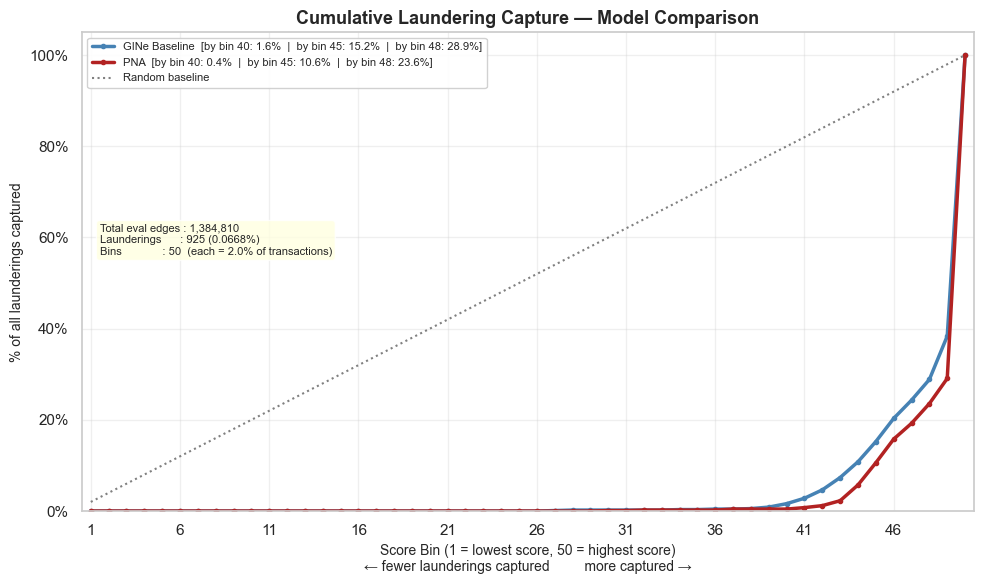

In [86]:
# ── Usage ─────────────────────────────────────────────────────────────────────
plot_laundering_cdf_comparison(
    y_true       = y_true_test,
    scores_dict  = {
        'GINe Baseline' : y_score_test,
        'PNA'           : y_score_test_pna,
    },
    n_bins = 50,
)

In [134]:
df_train

,split,src_idx,dst_idx,timestamp,score,label,pred_thr05
0,train,606674,53721,1661990400,0.000531,0,0
1,train,255381,255381,1661990400,0.000174,0,0
2,train,578237,72342,1661990400,0.000258,0,0
3,train,536323,510825,1661990400,0.001254,0,0
4,train,424220,478017,1661990400,0.000520,0,0
...,...,...,...,...,...,...,...
4154424,train,230080,247572,1662471120,0.000257,0,0
4154425,train,570557,590994,1662471120,0.001121,0,0
4154426,train,686684,438637,1662471120,0.000257,0,0
4154427,train,264331,113349,1662471120,0.000263,0,0


# Model Predictive Power on different laundering structures

In [287]:
# ── Step 1: Load raw CSV with row index ──────────────────────────────────────
col_names = [
    'Timestamp', 'From Bank', 'src_account',
    'To Bank',   'dst_account',
    'Amount Received', 'Receiving Currency',
    'Amount Paid', 'Payment Currency',
    'Payment Format', 'label'
]

df_raw = pd.read_csv(
    'Data/LI-Small_Trans.csv',
    names=col_names,
    header=0,
    low_memory=False
)
df_raw['Timestamp'] = pd.to_datetime(df_raw['Timestamp'])

print(f"Raw CSV: {len(df_raw):,} rows")
print(df_raw[['Timestamp', 'src_account', 'dst_account', 'label']].head(3))

# ── Step 2: Add src_idx / dst_idx to raw CSV using account_to_idx ────────────
with open('Data/account_to_idx.pkl', 'rb') as f:
    account_to_idx = pickle.load(f)

df_raw['src_idx'] = df_raw['src_account'].map(account_to_idx)
df_raw['dst_idx'] = df_raw['dst_account'].map(account_to_idx)
df_raw['timestamp_unix'] = df_raw['Timestamp'].astype(np.int64) // 10**9

print(f"\nUnmapped src accounts: {df_raw['src_idx'].isna().sum():,}")
print(f"Unmapped dst accounts: {df_raw['dst_idx'].isna().sum():,}")

Raw CSV: 6,924,049 rows
            Timestamp src_account dst_account  label
0 2022-09-01 00:08:00   8000ECA90   8000ECA90      0
1 2022-09-01 00:21:00   80021DAD0   80021DAD0      0
2 2022-09-01 00:00:00   8000ECA90   8006AA910      0

Unmapped src accounts: 0
Unmapped dst accounts: 0


In [298]:
# Also need amount in patterns parser — add it
def parse_patterns_file_raw(filepath):
    records      = []
    attempt_id   = 0
    pattern_type = None

    begin_re = re.compile(r'BEGIN LAUNDERING ATTEMPT\s*-\s*([\w-]+)', re.IGNORECASE)
    end_re   = re.compile(r'END LAUNDERING ATTEMPT',                   re.IGNORECASE)

    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            m = begin_re.search(line)
            if m:
                attempt_id  += 1
                pattern_type = m.group(1).upper()
                continue
            if end_re.search(line):
                pattern_type = None
                continue
            if pattern_type is None:
                continue
            parts = [p.strip() for p in line.split(',')]
            if len(parts) < 11:
                continue
            try:
                records.append({
                    'Timestamp'     : pd.to_datetime(parts[0], format='%Y/%m/%d %H:%M'),
                    'src_bank'      : str(parts[1]).lstrip('0'),
                    'src_account'   : parts[2],
                    'dst_bank'      : str(parts[3]).lstrip('0'),
                    'dst_account'   : parts[4],
                    'Amount Received': float(parts[5]),
                    'Payment Format': parts[9],
                    'pattern_type'  : pattern_type,
                    'attempt_id'    : attempt_id,
                    'label'         : 1,
                })
            except (ValueError, IndexError):
                continue

    df_pat = pd.DataFrame(records)
    print(f"Parsed {len(df_pat):,} transactions across {attempt_id:,} attempts")
    return df_pat


df_patterns_raw = parse_patterns_file_raw('Data/LI-Small_Patterns.txt')

Parsed 1,023 transactions across 117 attempts


In [304]:
df_raw['From Bank'] = df_raw['From Bank'].astype(str).str.lstrip('0')
df_raw['To Bank']   = df_raw['To Bank'].astype(str).str.lstrip('0')
df_patterns_raw['src_bank'] = df_patterns_raw['src_bank'].astype(str).str.lstrip('0')
df_patterns_raw['dst_bank'] = df_patterns_raw['dst_bank'].astype(str).str.lstrip('0')

In [307]:
df_raw_enriched = df_raw.rename(columns={'From Bank': 'src_bank', 'To Bank': 'dst_bank'}).merge(
    df_patterns_raw[['Timestamp', 'src_account', 'dst_account',
                      'src_bank',  'dst_bank',
                      'Amount Received', 'Payment Format',
                      'pattern_type', 'attempt_id', 'label']],
    on =['Timestamp', 'src_account', 'dst_account',
               'src_bank', 'dst_bank',
               'Amount Received', 'Payment Format', 'label'],
    how='left'
)

In [311]:
df_raw_enriched['category'] = 'LEGIT'
df_raw_enriched.loc[(df_raw_enriched['label']==1) & (df_raw_enriched['pattern_type'].notna()), 'category'] = 'PATTERN_LAUNDERING'
df_raw_enriched.loc[(df_raw_enriched['label']==1) & (df_raw_enriched['pattern_type'].isna()),  'category'] = 'INTEGRATION_LAUNDERING'

In [324]:
df_all_enriched = df_all.merge(df_raw_enriched[['src_idx', 'dst_idx', 'timestamp_unix', 'category', 'pattern_type', 'attempt_id', 'label']].rename(columns={'timestamp_unix': 'timestamp'}).drop_duplicates(),
                               on=['src_idx', 'dst_idx', 'timestamp', 'label'],
                               how='left')

df_all_enriched_pna = df_all_pna.merge(df_raw_enriched[['src_idx', 'dst_idx', 'timestamp_unix', 'category', 'pattern_type', 'attempt_id', 'label']].rename(columns={'timestamp_unix': 'timestamp'}).drop_duplicates(),
                                       on=['src_idx', 'dst_idx', 'timestamp', 'label'],
                                       how='left')

In [325]:
df_all_enriched.shape, df_all_enriched_pna.shape

((6924049, 10), (6924049, 9))

In [326]:
df_all.shape, df_all_pna.shape

((6924049, 7), (6924049, 6))

In [327]:
df_all_enriched

,split,src_idx,dst_idx,timestamp,score,label,pred_thr05,category,pattern_type,attempt_id
0,train,606674,53721,1661990400,0.000531,0,0.0,LEGIT,NaN,NaN
1,train,255381,255381,1661990400,0.000174,0,0.0,LEGIT,NaN,NaN
2,train,578237,72342,1661990400,0.000258,0,0.0,LEGIT,NaN,NaN
3,train,536323,510825,1661990400,0.001254,0,0.0,LEGIT,NaN,NaN
4,train,424220,478017,1661990400,0.000520,0,0.0,LEGIT,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
6924044,test,240862,240862,1663334640,0.000248,0,NaN,LEGIT,NaN,NaN
6924045,test,240862,94532,1663334640,0.279557,1,NaN,PATTERN_LAUNDERING,GATHER-SCATTER,113.0
6924046,test,505341,505341,1663381920,0.000298,0,NaN,LEGIT,NaN,NaN
6924047,test,505341,339730,1663381920,0.117105,1,NaN,PATTERN_LAUNDERING,GATHER-SCATTER,101.0


In [329]:
# Mean/median score per category
print("\nScore distribution by category GINe:")
df_all_enriched.groupby('category')['score'].agg(['mean','median','std','count']).round(4)


Score distribution by category GINe:


,mean,median,std,count
category,,,,
INTEGRATION_LAUNDERING,0.2728,0.2012,0.2227,2542
LEGIT,0.0166,0.0003,0.0574,6920484
PATTERN_LAUNDERING,0.4355,0.5185,0.1970,1023


In [330]:
print("\nScore distribution by category PNA:")
df_all_enriched_pna.groupby('category')['score'].agg(['mean','median','std','count']).round(4)


Score distribution by category PNA:


,mean,median,std,count
category,,,,
INTEGRATION_LAUNDERING,0.1112,0.0424,0.1341,2542
LEGIT,0.0021,0.0000,0.0169,6920484
PATTERN_LAUNDERING,0.5130,0.6331,0.3566,1023


In [335]:
df_all_enriched.head()

,split,src_idx,dst_idx,timestamp,score,label,pred_thr05,category,pattern_type,attempt_id
0,train,606674,53721,1661990400,0.000531,0,0.0,LEGIT,NaN,NaN
1,train,255381,255381,1661990400,0.000174,0,0.0,LEGIT,NaN,NaN
2,train,578237,72342,1661990400,0.000258,0,0.0,LEGIT,NaN,NaN
3,train,536323,510825,1661990400,0.001254,0,0.0,LEGIT,NaN,NaN
4,train,424220,478017,1661990400,0.000520,0,0.0,LEGIT,NaN,NaN


In [336]:
df_all_enriched['pattern_type'].value_counts()

pattern_type
SCATTER-GATHER    182
STACK             180
GATHER-SCATTER    150
FAN-OUT           149
BIPARTITE         129
CYCLE              83
RANDOM             77
FAN-IN             73
Name: count, dtype: int64

In [337]:
def comprehensive_pattern_analysis(df_gine, df_pna, threshold=0.5):
    """
    Comprehensive analysis of model performance by category and pattern type.
    Covers: score distributions, recall by split, attempt-level detection,
    and pattern-type breakdown — for both models side by side.
    """

    models = {'GINe': df_gine, 'PNA': df_pna}

    # ── 1. Score Distribution by Category & Split ─────────────────────────────
    print("=" * 70)
    print("1. SCORE DISTRIBUTION BY CATEGORY")
    print("=" * 70)
    for model_name, df in models.items():
        print(f"\n--- {model_name} ---")
        print(
            df.groupby(['split', 'category'])['score']
            .agg(['mean', 'median', 'std', 'count'])
            .round(4)
            .to_string()
        )

    # ── 2. Recall by Category at Multiple Thresholds ──────────────────────────
    print("\n" + "=" * 70)
    print("2. RECALL BY CATEGORY AT DIFFERENT THRESHOLDS")
    print("=" * 70)
    for model_name, df in models.items():
        print(f"\n--- {model_name} (test split only) ---")
        df_test = df[df['split'] == 'test']
        rows = []
        for thr in [0.1, 0.3, 0.5]:
            for cat in ['PATTERN_LAUNDERING', 'INTEGRATION_LAUNDERING']:
                subset = df_test[df_test['category'] == cat]
                caught = (subset['score'] >= thr).sum()
                total  = len(subset)
                rows.append({
                    'threshold' : thr,
                    'category'  : cat,
                    'caught'    : caught,
                    'total'     : total,
                    'recall'    : f"{100*caught/max(total,1):.1f}%"
                })
        print(pd.DataFrame(rows).pivot(
            index='category', columns='threshold', values='recall'
        ).to_string())

    # ── 3. Recall by Pattern Type (test split) ────────────────────────────────
    print("\n" + "=" * 70)
    print("3. RECALL BY PATTERN TYPE @ threshold=0.5 (test split)")
    print("=" * 70)
    rows = []
    for model_name, df in models.items():
        df_test = df[(df['split'] == 'test') & (df['category'] == 'PATTERN_LAUNDERING')]
        for pat, grp in df_test.groupby('pattern_type'):
            caught = (grp['score'] >= threshold).sum()
            rows.append({
                'model'       : model_name,
                'pattern_type': pat,
                'total'       : len(grp),
                'caught'      : caught,
                'recall'      : f"{100*caught/max(len(grp),1):.1f}%",
                'mean_score'  : round(grp['score'].mean(), 4),
            })
    df_pat = pd.DataFrame(rows)
    print(df_pat.pivot(index='pattern_type', columns='model',
                       values=['recall', 'mean_score']).to_string())

    # ── 4. Attempt-Level Detection ────────────────────────────────────────────
    print("\n" + "=" * 70)
    print("4. ATTEMPT-LEVEL DETECTION (any transaction caught = attempt detected)")
    print("=" * 70)
    for model_name, df in models.items():
        print(f"\n--- {model_name} ---")
        df_pat = df[df['category'] == 'PATTERN_LAUNDERING']
        attempt_stats = (
            df_pat.groupby(['attempt_id', 'pattern_type'])
            .apply(lambda g: pd.Series({
                'n_trans'       : len(g),
                'any_caught'    : (g['score'] >= threshold).any(),
                'all_caught'    : (g['score'] >= threshold).all(),
                'mean_score'    : g['score'].mean(),
            }))
            .reset_index()
        )
        summary = (
            attempt_stats.groupby('pattern_type')
            .agg(
                attempts        = ('n_trans', 'count'),
                any_caught_rate = ('any_caught', 'mean'),
                all_caught_rate = ('all_caught', 'mean'),
                mean_score      = ('mean_score', 'mean'),
            )
            .round(3)
            .sort_values('any_caught_rate', ascending=False)
        )
        summary['any_caught_rate'] = summary['any_caught_rate'].map('{:.1%}'.format)
        summary['all_caught_rate'] = summary['all_caught_rate'].map('{:.1%}'.format)
        print(summary.to_string())

        total_attempts = len(attempt_stats)
        any_caught     = attempt_stats['any_caught'].sum()
        all_caught     = attempt_stats['all_caught'].sum()
        print(f"\n  Overall: {any_caught}/{total_attempts} attempts "
              f"have ≥1 transaction caught ({100*any_caught/max(total_attempts,1):.1f}%)")
        print(f"  Overall: {all_caught}/{total_attempts} attempts "
              f"fully caught ({100*all_caught/max(total_attempts,1):.1f}%)")

    # ── 5. Score Distribution Plot ────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    bins = np.linspace(0, 1, 60)

    for ax, (model_name, df) in zip(axes, models.items()):
        df_test = df[df['split'] == 'test']
        for cat, color, alpha in [
            ('LEGIT',                  'steelblue',  0.5),
            ('INTEGRATION_LAUNDERING', 'darkorange', 0.7),
            ('PATTERN_LAUNDERING',     'firebrick',  0.8),
        ]:
            subset = df_test[df_test['category'] == cat]['score']
            ax.hist(subset, bins=bins, alpha=alpha, color=color,
                    density=True, label=f'{cat} (n={len(subset):,})')

        ax.axvline(threshold, color='black', linestyle='--',
                   linewidth=1.5, label=f'Threshold={threshold}')
        ax.set_xlabel('Model Score', fontsize=10)
        ax.set_ylabel('Density (log scale)', fontsize=10)
        ax.set_title(f'{model_name} — Score Distribution by Category\n(test split)',
                     fontsize=12, fontweight='bold')
        ax.set_yscale('log')
        ax.legend(fontsize=8, framealpha=0.9)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── 6. Pattern Type Mean Score Comparison Plot ────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    x      = None
    width  = 0.35
    colors = {'GINe': 'steelblue', 'PNA': 'firebrick'}

    pat_scores = {}
    for model_name, df in models.items():
        df_test = df[(df['split'] == 'test') & (df['label'] == 1)]
        pat_scores[model_name] = (
            df_test.groupby('pattern_type', dropna=False)['score']
            .mean()
            .sort_index()
        )

    categories = sorted(set(
        list(pat_scores['GINe'].index) + list(pat_scores['PNA'].index)
    ), key=lambda x: str(x))
    x = np.arange(len(categories))

    for i, (model_name, scores) in enumerate(pat_scores.items()):
        vals = [scores.get(c, 0) for c in categories]
        bars = ax.bar(x + i*width - width/2, vals, width=width,
                      color=colors[model_name], alpha=0.8, label=model_name)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.2f}', ha='center', fontsize=7, color=colors[model_name],
                    fontweight='bold')

    ax.axhline(threshold, color='black', linestyle='--',
               linewidth=1.2, label=f'Threshold={threshold}')
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('Mean Score', fontsize=10)
    ax.set_title('Mean Model Score by Pattern Type (test split, laundering only)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

1. SCORE DISTRIBUTION BY CATEGORY

--- GINe ---
                                mean  median     std    count
split category                                               
test  INTEGRATION_LAUNDERING  0.2668  0.1896  0.2201      582
      LEGIT                   0.0170  0.0003  0.0573  1383885
      PATTERN_LAUNDERING      0.4146  0.5064  0.2059      343
train INTEGRATION_LAUNDERING  0.2865  0.2352  0.2283     1384
      LEGIT                   0.0167  0.0003  0.0593  4152616
      PATTERN_LAUNDERING      0.4835  0.5540  0.1682      429
val   INTEGRATION_LAUNDERING  0.2459  0.1494  0.2089      576
      LEGIT                   0.0161  0.0003  0.0513  1383983
      PATTERN_LAUNDERING      0.3818  0.4408  0.2115      251

--- PNA ---
                                mean  median     std    count
split category                                               
test  INTEGRATION_LAUNDERING  0.1027  0.0379  0.1272      582
      LEGIT                   0.0021  0.0000  0.0165  1383885
      PAT

C:\Users\User\AppData\Local\Temp\ipykernel_17972\4198660581.py:77: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
C:\Users\User\AppData\Local\Temp\ipykernel_17972\4198660581.py:77: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


                attempts any_caught_rate all_caught_rate  mean_score
pattern_type                                                        
FAN-OUT               19           89.5%           21.1%       0.642
BIPARTITE             16           87.5%            0.0%       0.417
CYCLE                 12           75.0%           16.7%       0.497
FAN-IN                12           75.0%            0.0%       0.408
GATHER-SCATTER        12           66.7%            0.0%       0.345
RANDOM                15           66.7%            0.0%       0.368
SCATTER-GATHER        13           61.5%            0.0%       0.321
STACK                 18           61.1%           11.1%       0.446

  Overall: 86/117 attempts have ≥1 transaction caught (73.5%)
  Overall: 8/117 attempts fully caught (6.8%)


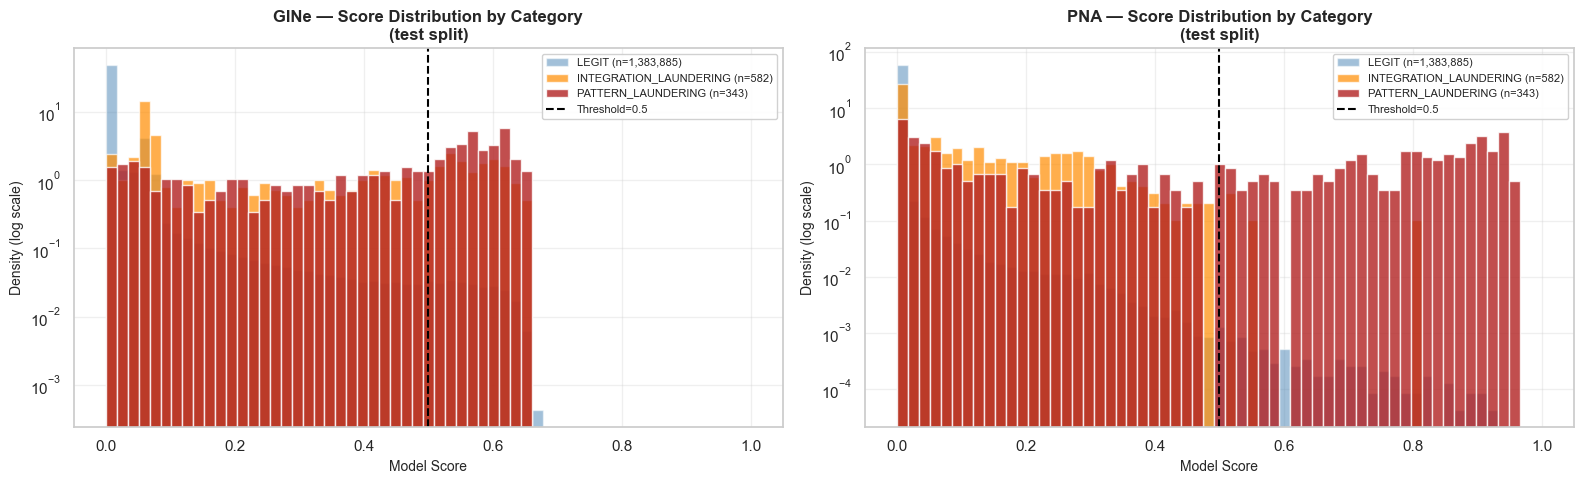

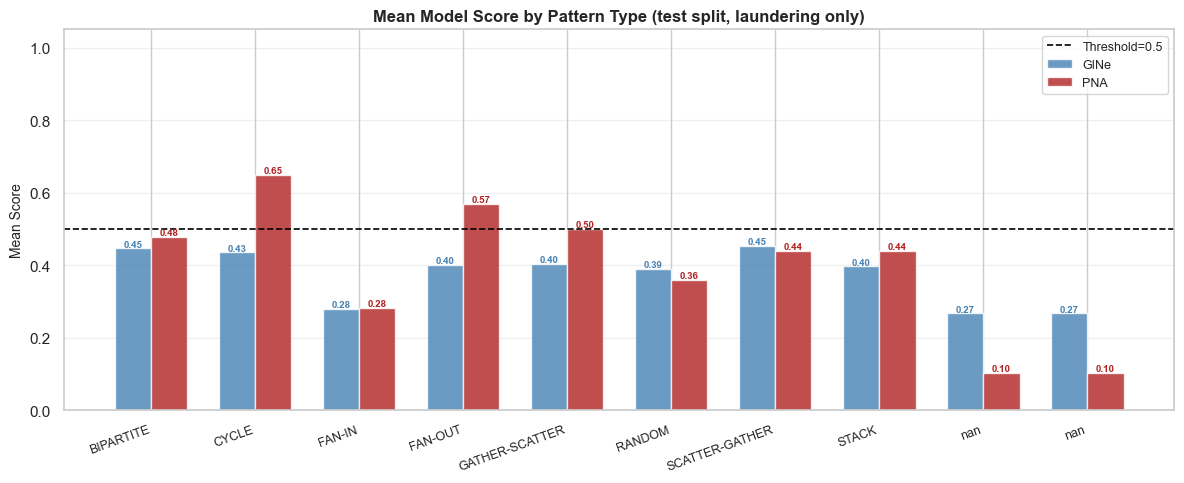

In [338]:
# ── Usage ─────────────────────────────────────────────────────────────────────
comprehensive_pattern_analysis(df_all_enriched, df_all_enriched_pna, threshold=0.5)

In [354]:
def evaluate_by_pattern_type(data, model_name, n_bootstrap=20,
                              laund_ratio=0.10, random_seed=42):
    """
    For each laundering category/pattern type, evaluates model performance
    by sampling legit transactions to achieve a target laundering ratio,
    repeated n_bootstrap times.

    Metrics computed per bootstrap sample:
      - ROC-AUC   (threshold-independent)
      - PR-AUC    (threshold-independent, sensitive to class imbalance)
      - F1        (best threshold found on each sample)
      - MCC       (best threshold found on each sample)

    Parameters
    ----------
    data           : enriched predictions DataFrame with 'category', 'pattern_type',
                   'score', 'label' columns
    model_name   : string label for display
    n_bootstrap  : number of bootstrap samples per pattern type
    laund_ratio  : target laundering proportion (0.10 = 10% laundering, 90% legit)
    random_seed  : base random seed

    Returns
    -------
    df_results : DataFrame with mean/std of each metric per pattern type
    """
    rng = np.random.default_rng(random_seed)

    df = data.copy()

    # All legit transactions (used for sampling)
    legit_scores = df[df['category'] == 'LEGIT']['score'].values
    legit_labels = np.zeros(len(legit_scores), dtype=int)

    # ── Define groups ─────────────────────────────────────────────────────────
    groups = {}

    # Named pattern types — only from PATTERN_LAUNDERING category
    # pattern_type is never NaN here (NaN = INTEGRATION by definition)
    for pat in sorted(
        df[df['category'] == 'PATTERN_LAUNDERING']['pattern_type'].dropna().unique()
    ):
        subset = df[df['pattern_type'] == pat]
        groups[pat] = (subset['score'].values, subset['label'].values)

    # Integration laundering — label=1 rows with no named pattern
    # Use category column directly, NOT pattern_type, to avoid NaN issues
    integ = df[df['category'] == 'INTEGRATION_LAUNDERING']
    groups['INTEGRATION (Other)'] = (integ['score'].values, integ['label'].values)

    # All laundering combined
    all_laund = df[df['label'] == 1]
    groups['ALL_LAUNDERING'] = (all_laund['score'].values, all_laund['label'].values)

    # ── Threshold-dependent metrics ───────────────────────────────────────────
    def best_threshold_metrics(y_true, y_score):
        pre, rec, thresholds = precision_recall_curve(y_true, y_score)
        f1_scores = 2 * pre * rec / (pre + rec + 1e-8)
        best_f1   = f1_scores.max()

        candidates = np.linspace(y_score.min(), y_score.max(), 200)
        best_mcc   = -1.0
        for thr in candidates:
            preds = (y_score >= thr).astype(int)
            if preds.sum() == 0:
                continue
            mcc = matthews_corrcoef(y_true, preds)
            if mcc > best_mcc:
                best_mcc = mcc

        return best_f1, best_mcc

    # ── Bootstrap loop with progress bar ─────────────────────────────────────
    all_results = []
    total_iters = len(groups) * n_bootstrap

    with tqdm(total=total_iters,
              desc=f'{model_name}',
              bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]') as pbar:

        for group_name, (laund_scores, laund_true) in groups.items():
            n_laund = len(laund_scores)
            if n_laund == 0:
                pbar.update(n_bootstrap)
                continue

            n_legit_sample = int(n_laund * (1 - laund_ratio) / laund_ratio)
            n_legit_sample = min(n_legit_sample, len(legit_scores))
            actual_ratio   = n_laund / (n_laund + n_legit_sample)

            bootstrap_metrics = []

            for i in range(n_bootstrap):
                pbar.set_postfix({
                    'group'    : group_name,
                    'n_laund'  : n_laund,
                    'bootstrap': f'{i+1}/{n_bootstrap}'
                })

                idx     = rng.choice(len(legit_scores), size=n_legit_sample, replace=False)
                y_score = np.concatenate([laund_scores, legit_scores[idx]])
                y_true  = np.concatenate([laund_true,   legit_labels[idx]])

                with warnings.catch_warnings():
                    warnings.simplefilter('ignore')
                    try:
                        roc_auc = roc_auc_score(y_true, y_score)
                        pr_auc  = average_precision_score(y_true, y_score)
                        f1, mcc = best_threshold_metrics(y_true, y_score)
                        bootstrap_metrics.append({
                            'roc_auc': roc_auc,
                            'pr_auc' : pr_auc,
                            'f1'     : f1,
                            'mcc'    : mcc,
                        })
                    except ValueError:
                        pass

                pbar.update(1)

            if not bootstrap_metrics:
                continue

            bm = pd.DataFrame(bootstrap_metrics)
            all_results.append({
                'model'         : model_name,
                'group'         : group_name,
                'n_laundering'  : n_laund,
                'n_legit_sample': n_legit_sample,
                'actual_ratio'  : f"{100*actual_ratio:.1f}%",
                'roc_auc_mean'  : bm['roc_auc'].mean(),
                'roc_auc_std'   : bm['roc_auc'].std(),
                'pr_auc_mean'   : bm['pr_auc'].mean(),
                'pr_auc_std'    : bm['pr_auc'].std(),
                'f1_mean'       : bm['f1'].mean(),
                'f1_std'        : bm['f1'].std(),
                'mcc_mean'      : bm['mcc'].mean(),
                'mcc_std'       : bm['mcc'].std(),
            })

    return pd.DataFrame(all_results)

In [358]:
# ── Run for both models ───────────────────────────────────────────────────────
df_results_gine = evaluate_by_pattern_type(df_all_enriched,     'GINe', n_bootstrap=20, laund_ratio=0.01)
df_results_pna  = evaluate_by_pattern_type(df_all_enriched_pna, 'PNA',  n_bootstrap=20, laund_ratio=0.01)
df_results      = pd.concat([df_results_gine, df_results_pna], ignore_index=True)

PNA: 100%|██████████| 200/200 [15:52<00:00,  4.76s/it]


In [359]:
df_results

,model,group,n_laundering,n_legit_sample,actual_ratio,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,f1_mean,f1_std,mcc_mean,mcc_std
0,GINe,BIPARTITE,129,12771,1.0%,0.978934,0.000640,0.548024,0.022786,0.590567,0.016094,0.587090,0.016418
1,GINe,CYCLE,83,8217,1.0%,0.975600,0.001138,0.521665,0.042004,0.584133,0.025042,0.580698,0.024505
2,GINe,FAN-IN,73,7226,1.0%,0.985034,0.000655,0.507922,0.039081,0.608343,0.025048,0.610174,0.021803
3,GINe,FAN-OUT,149,14750,1.0%,0.986175,0.000424,0.589583,0.032234,0.623740,0.019212,0.620617,0.018693
4,GINe,GATHER-SCATTER,150,14850,1.0%,0.980126,0.000570,0.481364,0.035927,0.549279,0.019484,0.550323,0.018989
5,GINe,RANDOM,77,7623,1.0%,0.975999,0.000908,0.374780,0.035469,0.445340,0.017551,0.443065,0.019173
6,GINe,SCATTER-GATHER,182,18018,1.0%,0.986418,0.000373,0.558787,0.027168,0.625411,0.017287,0.630393,0.015239
7,GINe,STACK,180,17820,1.0%,0.983166,0.000314,0.507019,0.022441,0.542017,0.010219,0.548760,0.008716
8,GINe,INTEGRATION (Other),2542,251658,1.0%,0.955825,0.000252,0.242122,0.004197,0.348333,0.002713,0.343560,0.002384
9,GINe,ALL_LAUNDERING,3565,352935,1.0%,0.963285,0.000176,0.316189,0.003585,0.414292,0.002960,0.408769,0.002696



ROC_AUC (mean ± std over 20 bootstrap samples)
                              GINe            PNA
group                                            
BIPARTITE            0.979 ± 0.001  0.990 ± 0.000
CYCLE                0.976 ± 0.001  0.992 ± 0.000
FAN-IN               0.985 ± 0.001  0.989 ± 0.001
FAN-OUT              0.986 ± 0.000  0.994 ± 0.000
GATHER-SCATTER       0.980 ± 0.001  0.980 ± 0.000
RANDOM               0.976 ± 0.001  0.992 ± 0.000
SCATTER-GATHER       0.986 ± 0.000  0.990 ± 0.000
STACK                0.983 ± 0.000  0.987 ± 0.000
INTEGRATION (Other)  0.956 ± 0.000  0.967 ± 0.000
ALL_LAUNDERING       0.963 ± 0.000  0.973 ± 0.000

PR_AUC (mean ± std over 20 bootstrap samples)
                              GINe            PNA
group                                            
BIPARTITE            0.548 ± 0.023  0.796 ± 0.011
CYCLE                0.522 ± 0.042  0.873 ± 0.011
FAN-IN               0.508 ± 0.039  0.736 ± 0.017
FAN-OUT              0.590 ± 0.032  0.921 ± 0.006
GATHE

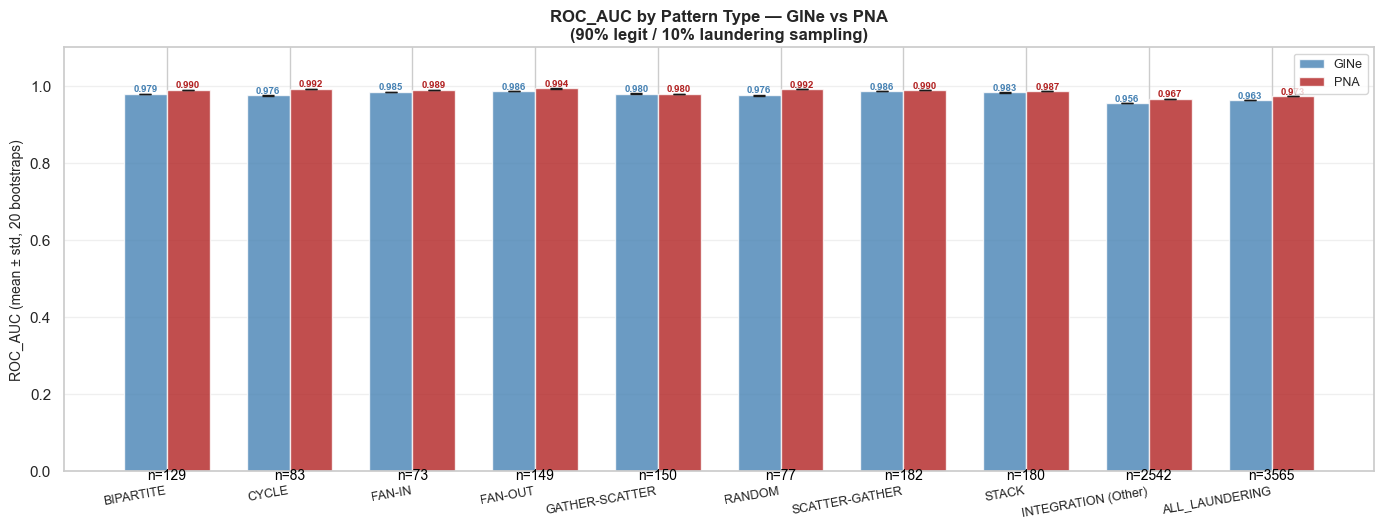

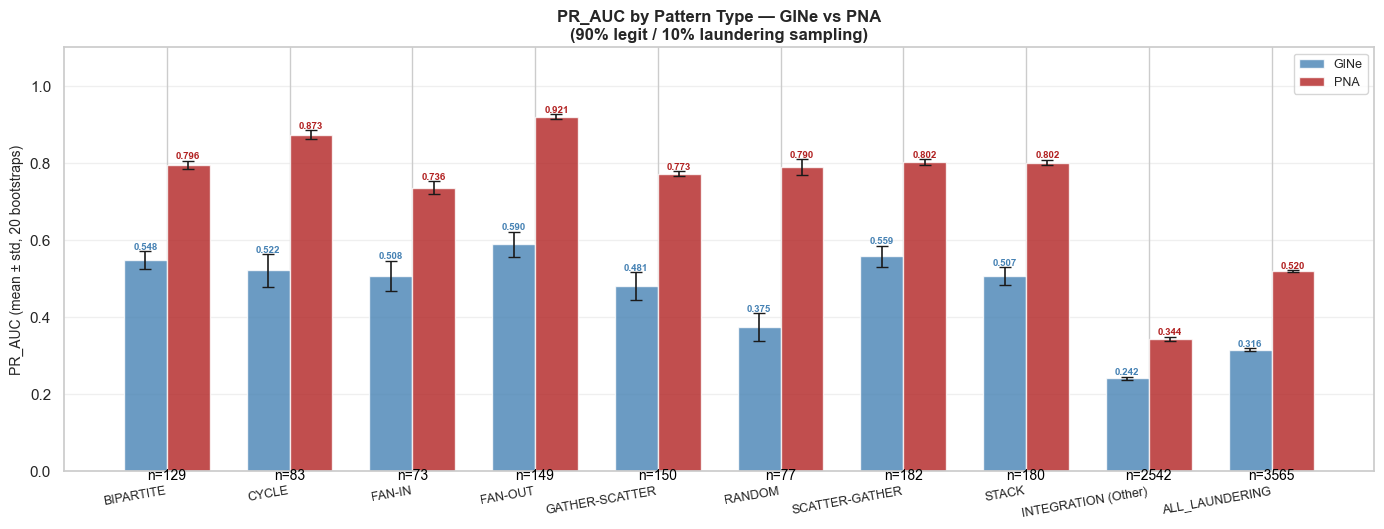

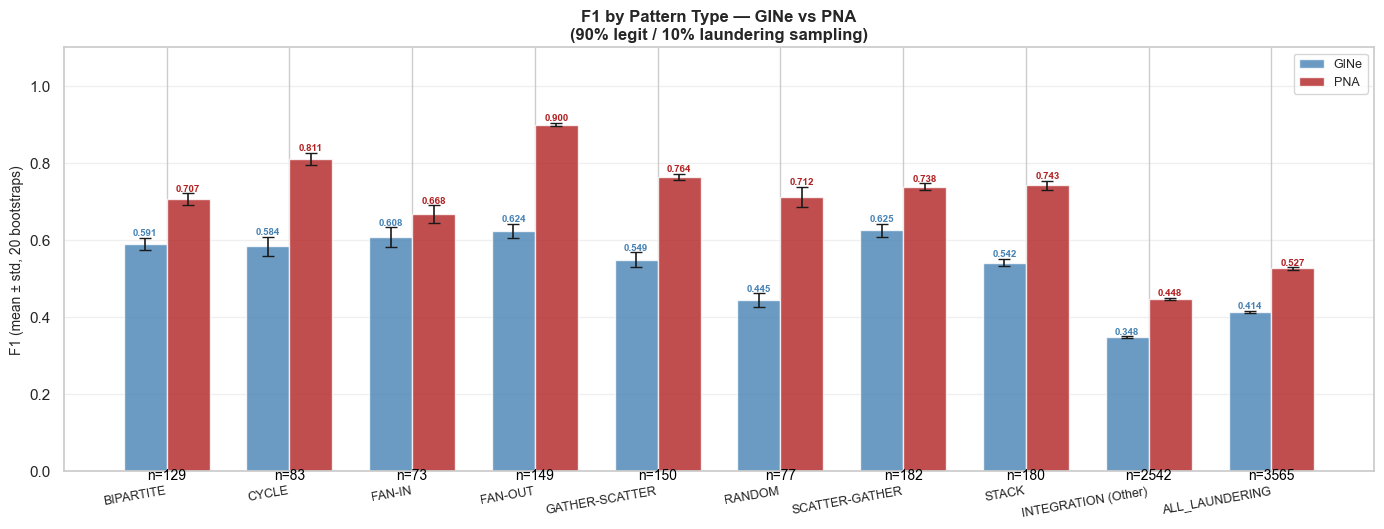

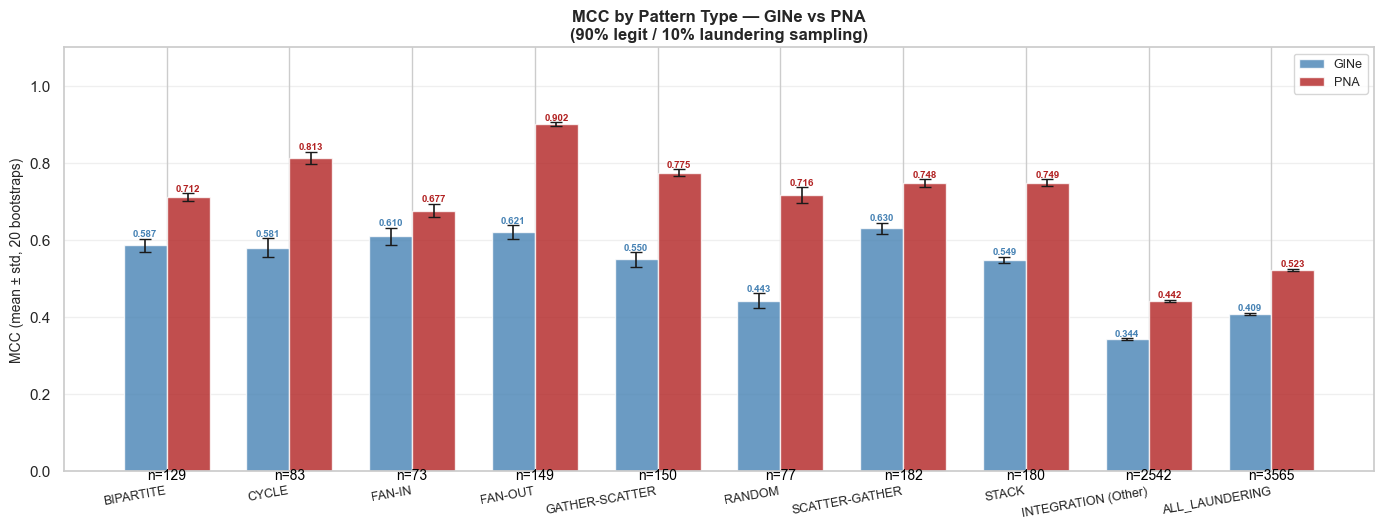

In [367]:
# ── Print results table ───────────────────────────────────────────────────────
def print_results(df_results):
    metrics = ['roc_auc', 'pr_auc', 'f1', 'mcc']
    for metric in metrics:
        print(f"\n{'='*70}")
        print(f"{metric.upper()} (mean ± std over {20} bootstrap samples)")
        print(f"{'='*70}")
        pivot = df_results.pivot(index='group', columns='model',
                                  values=[f'{metric}_mean', f'{metric}_std'])
        rows = []
        for group in df_results['group'].unique():
            row = {'group': group}
            for model in ['GINe', 'PNA']:
                sub = df_results[(df_results['group']==group) & 
                                  (df_results['model']==model)]
                if len(sub):
                    mean = sub[f'{metric}_mean'].iloc[0]
                    std  = sub[f'{metric}_std'].iloc[0]
                    row[model] = f"{mean:.3f} ± {std:.3f}"
            rows.append(row)
        print(pd.DataFrame(rows).set_index('group').to_string())

print_results(df_results)


# ── Visualise ─────────────────────────────────────────────────────────────────
def plot_bootstrap_results(df_results, metric='pr_auc'):
    groups  = df_results['group'].unique()
    models  = ['GINe', 'PNA']
    colors  = {'GINe': 'steelblue', 'PNA': 'firebrick'}
    x       = np.arange(len(groups))
    width   = 0.35

    fig, ax = plt.subplots(figsize=(14, 6))

    for i, model in enumerate(models):
        sub    = df_results[df_results['model'] == model].set_index('group')
        means  = [sub.loc[g, f'{metric}_mean'] if g in sub.index else 0 for g in groups]
        stds   = [sub.loc[g, f'{metric}_std']  if g in sub.index else 0 for g in groups]
        bars   = ax.bar(x + i*width - width/2, means, width=width,
                        color=colors[model], alpha=0.8, label=model,
                        yerr=stds, capsize=4, error_kw={'linewidth':1.2})
        for bar, mean, std in zip(bars, means, stds):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + std + 0.005,
                    f'{mean:.3f}', ha='center', fontsize=7,
                    color=colors[model], fontweight='bold')

    # Add n_laundering annotation below x-axis
    for j, group in enumerate(groups):
        n = df_results[df_results['group']==group]['n_laundering'].iloc[0]
        ax.text(j, -0.02, f'n={n}', ha='center', fontsize=10,
                color='black', transform=ax.get_xaxis_transform())

    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=10, ha='right', fontsize=9)
    ax.set_ylabel(f'{metric.upper()} (mean ± std, {20} bootstraps)', fontsize=10)
    ax.set_title(f'{metric.upper()} by Pattern Type — GINe vs PNA\n'
                 f'(90% legit / 10% laundering sampling)',
                 fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # Summary box
    for model in models:
        overall = df_results[(df_results['model']==model) & 
                             (df_results['group']=='ALL_LAUNDERING')]
        if len(overall):
            mean = overall[f'{metric}_mean'].iloc[0]
            std  = overall[f'{metric}_std'].iloc[0]

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)
    plt.show()

for metric in ['roc_auc', 'pr_auc', 'f1', 'mcc']:
    plot_bootstrap_results(df_results, metric=metric)

# Model performance without INTEGRATION (Other) typology

In [374]:
# GINe pr-auc

pr_gin, rec_gin, _ = precision_recall_curve(df_all_enriched[df_all_enriched['category'] != 'INTEGRATION_LAUNDERING']['label'], df_all_enriched[df_all_enriched['category'] != 'INTEGRATION_LAUNDERING']['score'])
pr_auc_gin = auc(rec_gin, pr_gin)

print(f"GINe PR-AUC (excluding integration laundering): {pr_auc_gin:.4f}")

GINe PR-AUC (excluding integration laundering): 0.0188


In [369]:
df_all_enriched['category'].value_counts()

category
LEGIT                     6920484
INTEGRATION_LAUNDERING       2542
PATTERN_LAUNDERING           1023
Name: count, dtype: int64

In [372]:
df_all_enriched

,split,src_idx,dst_idx,timestamp,score,label,pred_thr05,category,pattern_type,attempt_id
0,train,606674,53721,1661990400,0.000531,0,0.0,LEGIT,NaN,NaN
1,train,255381,255381,1661990400,0.000174,0,0.0,LEGIT,NaN,NaN
2,train,578237,72342,1661990400,0.000258,0,0.0,LEGIT,NaN,NaN
3,train,536323,510825,1661990400,0.001254,0,0.0,LEGIT,NaN,NaN
4,train,424220,478017,1661990400,0.000520,0,0.0,LEGIT,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
6924044,test,240862,240862,1663334640,0.000248,0,NaN,LEGIT,NaN,NaN
6924045,test,240862,94532,1663334640,0.279557,1,NaN,PATTERN_LAUNDERING,GATHER-SCATTER,113.0
6924046,test,505341,505341,1663381920,0.000298,0,NaN,LEGIT,NaN,NaN
6924047,test,505341,339730,1663381920,0.117105,1,NaN,PATTERN_LAUNDERING,GATHER-SCATTER,101.0
